## Questão 1 - Método Steepest Descend

In [12]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def steepest_descent(A,b,x0, tol=1e-6, max_iter = 30000):
    x = x0.copy()
    r = b - np.dot(A,x)
    x_hist = [x.copy()]
    alpha_hist = []
    for i in range(max_iter):
        if np.linalg.norm(r)<tol:
            break
        alpha = np.dot(r,r)/np.dot(r,np.dot(A,r))
        alpha_hist.append(alpha.copy())
        x = x+alpha*r
        r=r-alpha*np.dot(A,r)
        x_hist.append(x.copy())
    plt.figure(figsize=(5,5))
    plt.plot(range(len(alpha_hist)),alpha_hist,marker='o')
    plt.xlabel('Iteração')
    plt.ylabel(r'Valor de $\alpha$')
    plt.title(r'Valor de $\alpha$ em cada iteração')
    plt.grid(True)
    plt.show

    print('Numero total de iterações:', len(x_hist) -1)
    print('A solução encontrada é: ', x)
    print(' A norma L2 do erro é: ', np.linalg.norm(r))
    return np.array(x_hist)
    

In [46]:
m_A = ([2,-1,0,0],
    [-1,2,-1,0],
    [0,-1,2,-1],
    [0,0,-1,2])
b = ([1,0,0,0])
x_i = ([0,0,0,0])

[1. 0. 0. 0.]


Numero total de iterações: 63
A solução encontrada é:  [0.79999949 0.59999897 0.39999917 0.19999936]
 A norma L2 do erro é:  8.357863763810838e-07


array([[0.        , 0.        , 0.        , 0.        ],
       [0.5       , 0.        , 0.        , 0.        ],
       [0.5       , 0.25      , 0.        , 0.        ],
       [0.625     , 0.25      , 0.125     , 0.        ],
       [0.625     , 0.375     , 0.125     , 0.0625    ],
       [0.6875    , 0.375     , 0.21875   , 0.0625    ],
       [0.6875    , 0.453125  , 0.21875   , 0.109375  ],
       [0.7265625 , 0.453125  , 0.28125   , 0.109375  ],
       [0.7265625 , 0.50390625, 0.28125   , 0.140625  ],
       [0.75195312, 0.50390625, 0.32226562, 0.140625  ],
       [0.75195312, 0.53710938, 0.32226562, 0.16113281],
       [0.76855469, 0.53710938, 0.34912109, 0.16113281],
       [0.76855469, 0.55883789, 0.34912109, 0.17456055],
       [0.77941895, 0.55883789, 0.36669922, 0.17456055],
       [0.77941895, 0.57305908, 0.36669922, 0.18334961],
       [0.78652954, 0.57305908, 0.37820435, 0.18334961],
       [0.78652954, 0.58236694, 0.37820435, 0.18910217],
       [0.79118347, 0.58236694,

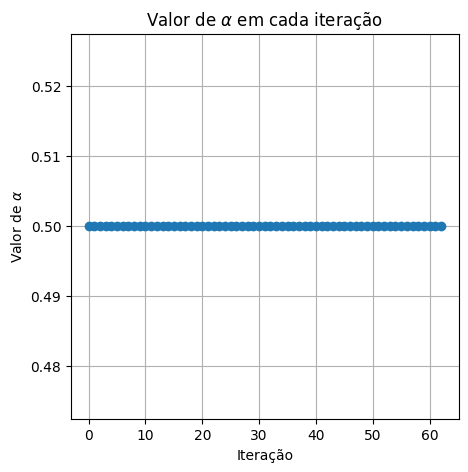

In [47]:
steepest_descent(m_A,v_b,x_i)

In [48]:
X_exato = np.linalg.solve(m_A,v_b)
X_exato

array([0.8, 0.6, 0.4, 0.2])

Como mostrado pelo código, os resultados são bem semelhantes, necessariamente idênticos, uma vez que o erro está na 7 casa decimal após a virugla. Portanto o método funciona bem e converge rápido, sem exigência computacional.

## Questão 2


[1, 0, 3, -2]


C:\Users\thiag\AppData\Local\Temp\ipykernel_15036\424441516.py:13: RuntimeWarning: invalid value encountered in scalar divide
  alpha = np.dot(r,r)/np.dot(r,np.dot(A,r))


Numero total de iterações: 30000
A solução encontrada é:  [nan nan nan nan]
 A norma L2 do erro é:  nan


array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [-0.36842105,  0.        , -1.10526316,  0.73684211],
       [-1.44413389, 13.64810664,  3.1975882 ,  6.65326272],
       ...,
       [        nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan],
       [        nan,         nan,         nan,         nan]])

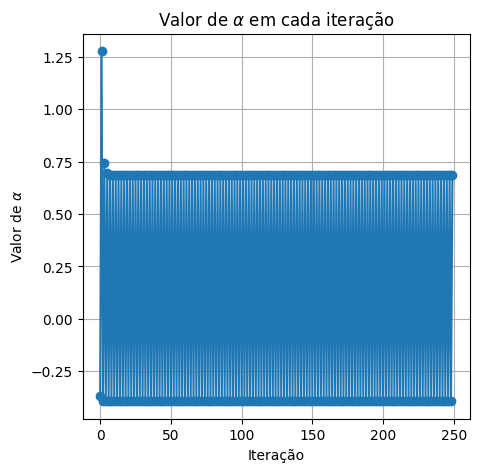

In [49]:
#Resolvendo por Steepest Descent:

m_A_2 = ([2,3,-1,2],
         [8,1,5,-3],
         [-1,4,2,2],
         [3,-2,3,-3])
v_b_2 = ([1,0,3,-2])
print(v_b_2)
steepest_descent(m_A_2,v_b_2,x_i)

In [ ]:
#Como mostra o print, o número de iterações é ultrapassado,
#e portanto não é possível resolver a matriz por esse método



In [50]:
#Verificando se a Matriz é Positiva Definida:

autovalores = np.linalg.eigvals(m_A_2)
resposta = np.all(autovalores >0)

print('Autovalores de m_A_2:',autovalores)
print('A Matriz é positiva definida:', resposta)

autovalores_m_A = np.linalg.eigvals(m_A)
resposta_m_A = np.all(autovalores_m_A >0)

print('Autovalores de m_A:',autovalores_m_A)
print('A Matriz é positiva definida:', resposta_m_A)

Autovalores de m_A_2: [-8.74924657  7.64458836  3.          0.1046582 ]
A Matriz é positiva definida: False
Autovalores de m_A: [3.61803399 2.61803399 0.38196601 1.38196601]
A Matriz é positiva definida: True


A solução não foi alcançada pois, quando a matriz não é positiva definida, as direções de descida são comprometidas, uma vez que autovalores zero, indicam a matriz é singular, e portanto, o sistema pode ter multiplas soluções, ou nenhuma solução unica.
Autovalores negativos, indicam que podem haver máximos e minimos LOCAIS, complicando a convergência do método, uma vez que ele começa a oscilar ou até divergir, em vez de diminuir ao longo das direções escolhidas.

Para a primeira matriz vemos que foi possível uma solução, e além disso a matriz é positiva definida, o que faz os valores de alpha não oscilarem.

# Questão 3

Autovalores de m_A: [1.22513073e+02 4.07234310e+01 9.75443409e+00 9.06170075e-03]
A Matriz é positiva definida: True
Numero total de iterações: 30000
A solução encontrada é:  [-1.37383129  4.40554451 -2.17624282 -5.82154417]
 A norma L2 do erro é:  0.000495712001125539


array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [-0.12161891,  0.33010848, -0.01737413,  0.24323783],
       [-0.03010028,  0.38333017,  0.07118512,  0.22309337],
       ...,
       [-1.37382885,  4.40553661, -2.17623794, -5.82153196],
       [-1.37383611,  4.40554211, -2.17624499, -5.82153767],
       [-1.37383129,  4.40554451, -2.17624282, -5.82154417]])

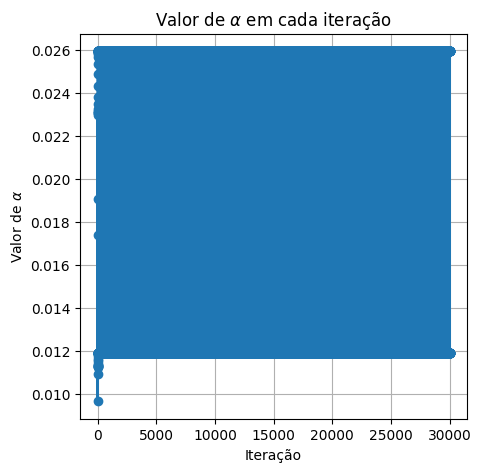

In [53]:
# A^T. A . x = A^T . b

m_A_2_T = np.transpose(m_A_2)
produto_m_A_T_A = np.dot(m_A_2_T,m_A_2)
produto_m_A_T_b = np.dot(m_A_2_T,v_b_2)
m_A_nova = produto_m_A_T_A
v_b_novo = produto_m_A_T_b
#Temos um sistema: produto_m_A_T_A . x = produto_m_A_T_b
# A´ x = b´

#Teste positividade

autovalores_m_A_nova = np.linalg.eigvals(m_A_nova)
resposta_m_A_nova = np.all(autovalores_m_A_nova >0)

print('Autovalores de m_A:',autovalores_m_A_nova)
print('A Matriz é positiva definida:', resposta_m_A_nova)

#Teste com a função:
steepest_descent(m_A_nova,v_b_novo,x_i,tol = 1e-6, max_iter = 30000)

In [52]:
sol = np.linalg.solve(m_A_nova,v_b_novo)
sol

array([-1.38095238,  4.42857143, -2.19047619, -5.85714286])

Uma vez que a matriz foi ajustada, a solução foi alcançada pelo método com uma boa precisão, com apenas algumas diferenças nas casas decimais. Foi necessário também, um maior numero de iterações.